In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the first sheet
df = pd.read_excel("online_retail_II.xlsx")

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 525461
Columns: 8


In [6]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


In [7]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [9]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [10]:
missing = df.isnull().sum()

print(missing)

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [11]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

Customer ID    20.539488
Description     0.557225
Invoice         0.000000
StockCode       0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64

In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Rows =", duplicates)

Duplicate Rows = 6865


In [13]:
df["Revenue"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [14]:
top_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_quantity)

Description
WHITE HANGING HEART T-LIGHT HOLDER    57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54698
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46106
ASSORTED COLOUR BIRD ORNAMENT         44925
60 TEATIME FAIRY CAKE CASES           36326
PACK OF 60 PINK PAISLEY CAKE CASES    31822
JUMBO BAG RED RETROSPOT               30727
SMALL POPCORN HOLDER                  29500
STRAWBERRY CERAMIC TRINKET BOX        26563
Name: Quantity, dtype: int64


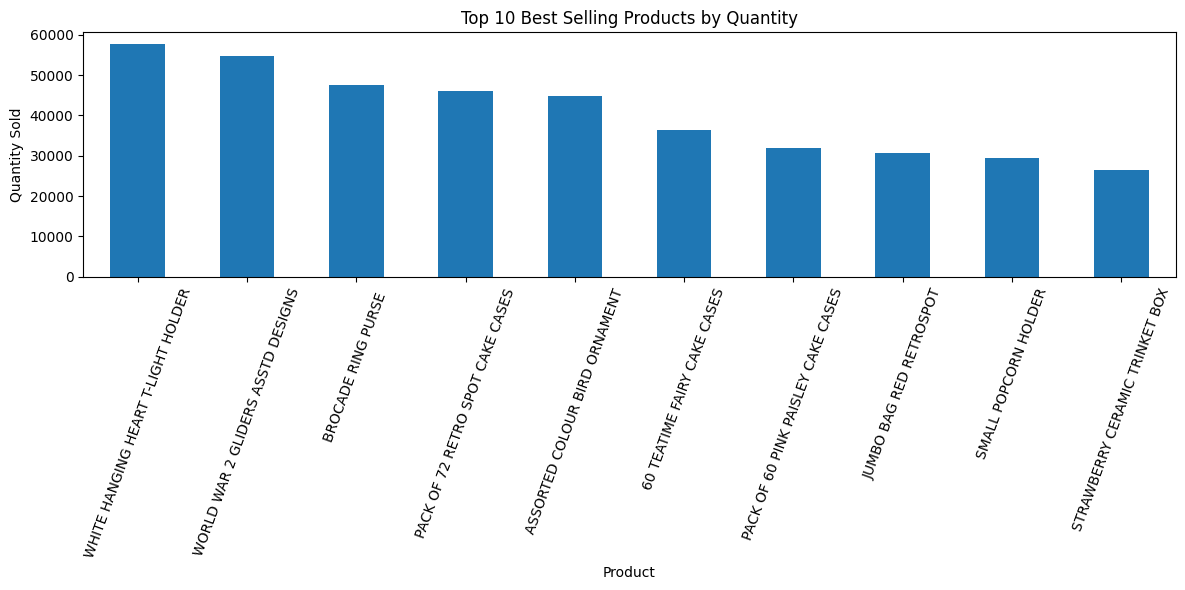

In [15]:
plt.figure(figsize=(12,6))

top_quantity.plot(kind="bar")

plt.title("Top 10 Best Selling Products by Quantity")

plt.xlabel("Product")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=70)

plt.tight_layout()

plt.show()

In [16]:
top_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_revenue)

Description
REGENCY CAKESTAND 3 TIER               163051.46
WHITE HANGING HEART T-LIGHT HOLDER     157865.43
DOTCOM POSTAGE                         116401.99
ASSORTED COLOUR BIRD ORNAMENT           72454.12
PAPER CHAIN KIT 50'S CHRISTMAS          57870.20
JUMBO BAG RED RETROSPOT                 56444.61
PARTY BUNTING                           49645.52
ROTATING SILVER ANGELS T-LIGHT HLDR     47672.49
POSTAGE                                 46092.36
JUMBO BAG STRAWBERRY                    36699.61
Name: Revenue, dtype: float64


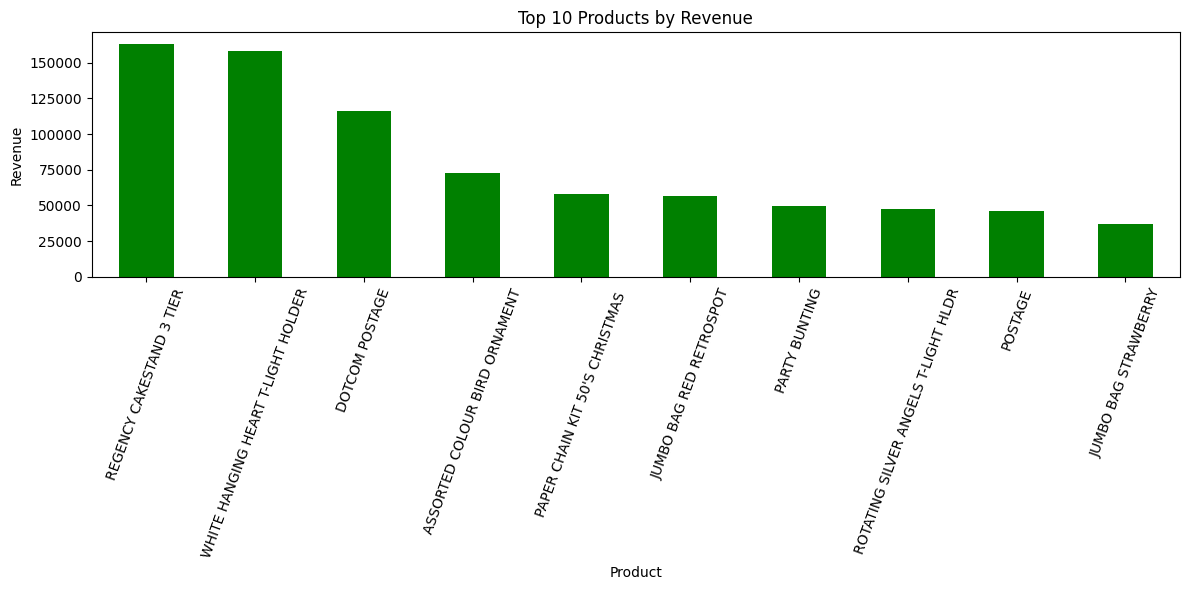

In [17]:
plt.figure(figsize=(12,6))

top_revenue.plot(kind="bar",color="green")

plt.title("Top 10 Products by Revenue")

plt.xlabel("Product")

plt.ylabel("Revenue")

plt.xticks(rotation=70)

plt.tight_layout()

plt.show()

In [18]:
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    8194777.533
EIRE               352242.730
Netherlands        263863.410
Germany            196290.351
France             130769.900
Sweden              51213.510
Denmark             46972.950
Switzerland         43343.410
Spain               37084.900
Australia           30051.800
Name: Revenue, dtype: float64

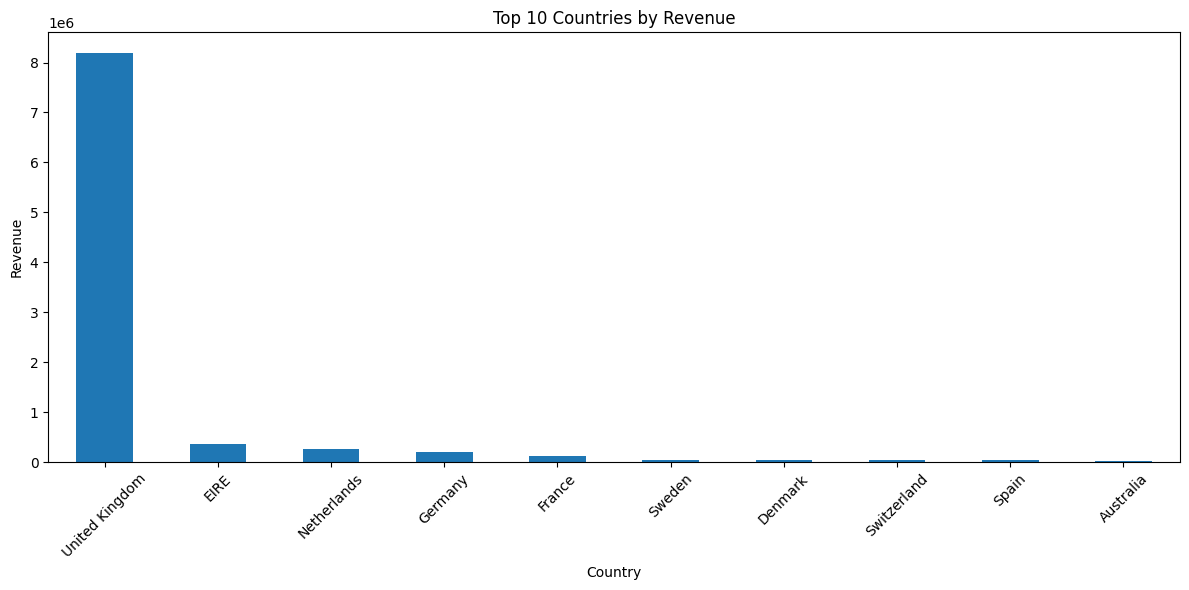

In [19]:
plt.figure(figsize=(12,6))

country_sales.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Country")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [20]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
)

monthly_sales

Month
2009-12     799847.110
2010-01     624032.892
2010-02     533091.426
2010-03     765848.761
2010-04     590580.432
2010-05     615322.830
2010-06     679786.610
2010-07     575236.360
2010-08     656776.340
2010-09     853650.431
2010-10    1045168.350
2010-11    1422654.642
2010-12     377488.450
Freq: M, Name: Revenue, dtype: float64

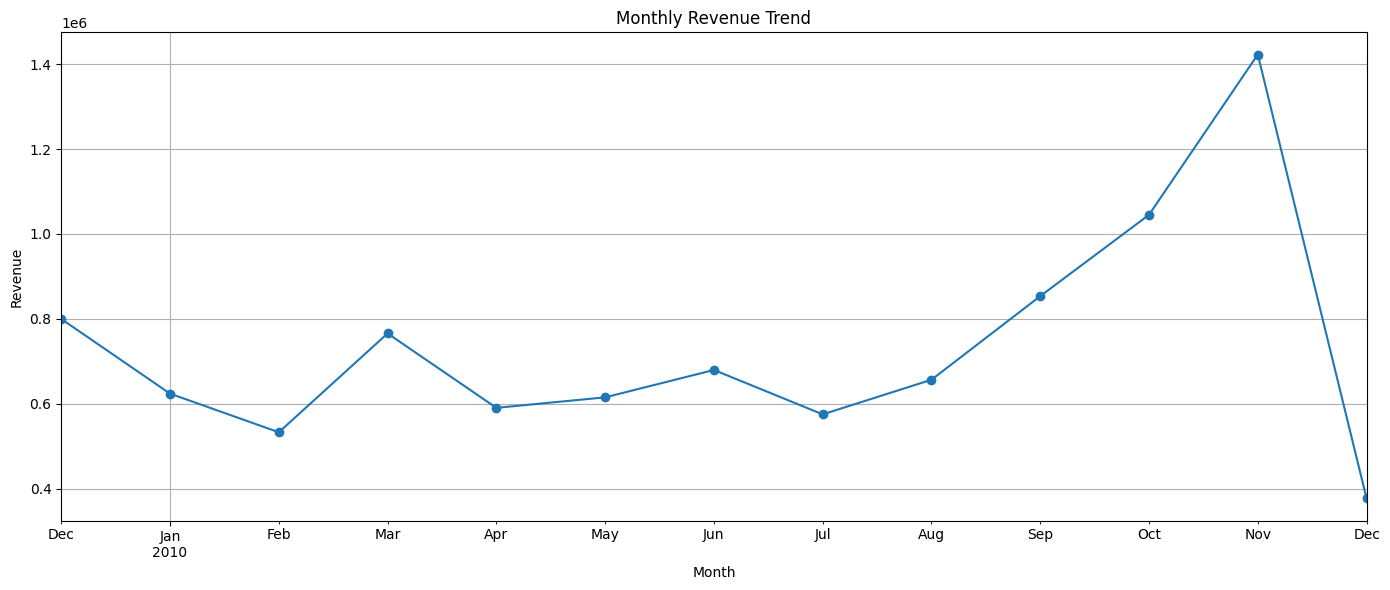

In [21]:
plt.figure(figsize=(14,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.tight_layout()

plt.show()

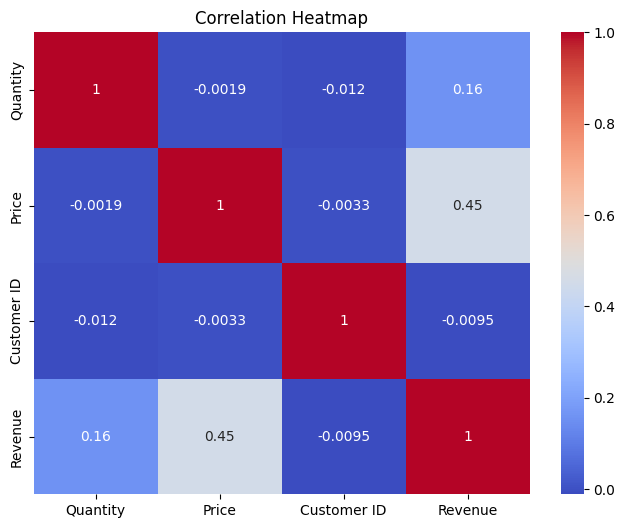

In [22]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

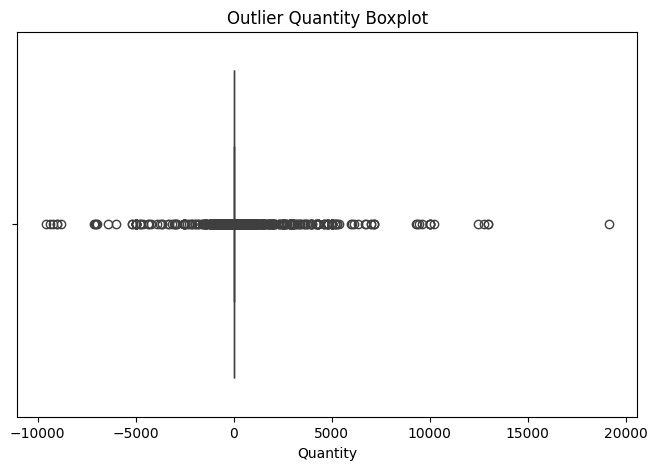

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Quantity"])

plt.title("Outlier Quantity Boxplot")

plt.show()

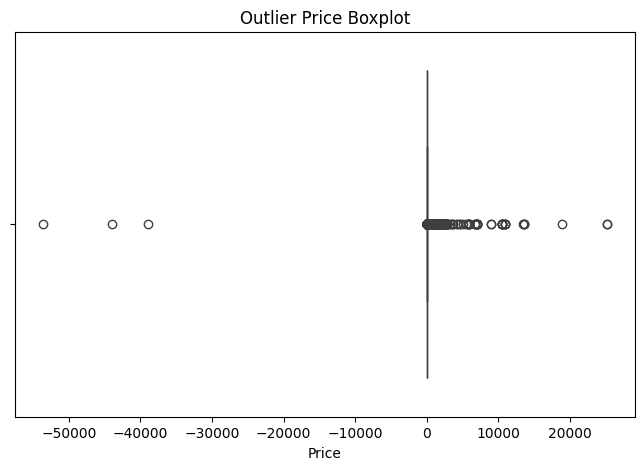

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Price"])

plt.title("Outlier Price Boxplot")

plt.show()

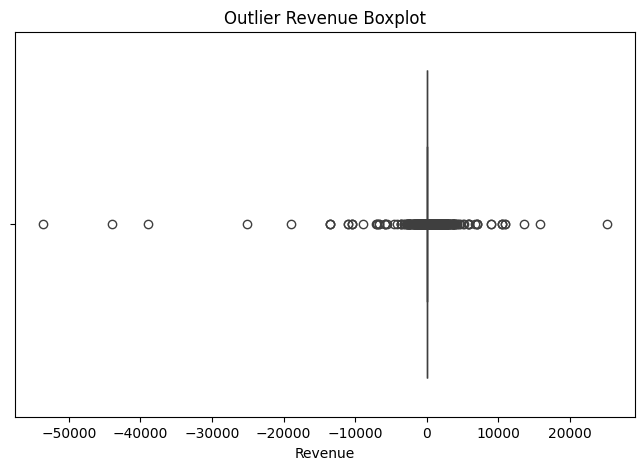

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Revenue"])

plt.title("Outlier Revenue Boxplot")

plt.show()

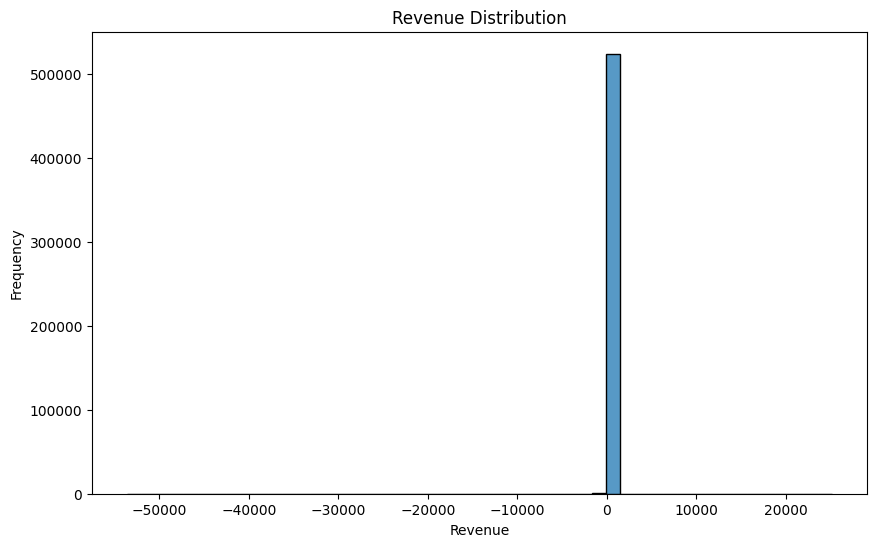

In [28]:
plt.figure(figsize=(10,6))

sns.histplot(df["Revenue"],bins=50)

plt.title("Revenue Distribution")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.show()

In [ ]:
# Business Insights

1. The United Kingdom contributes the highest revenue among all countries.

2. A small number of products account for a significant portion of total sales.

3. Some products are purchased in very large quantities, indicating high customer demand.

4. Missing Customer IDs and product descriptions indicate data quality issues that should be addressed during data cleaning in later stages.

5. Revenue changes from month to month, suggesting seasonal purchasing behavior.

6. Boxplots reveal extreme outliers in Quantity, Price, and Revenue, which may represent bulk purchases, returns, or data entry errors.

7. Positive correlation exists between Quantity and Revenue, while Price has a weaker relationship with Quantity.